In [3]:

import os, io, time, json, hashlib, pathlib, sys
import requests
import pandas as pd
import numpy as np
import importlib
from dotenv import load_dotenv
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import logging

from urllib.parse import urlparse
from datetime import datetime, timedelta
import geoquant.configs.config as config
import geoquant.data_io as f1
import geoquant.series_utils as f2
import geoquant.risk_matrix as risk_matrix
import geoquant.books as books

# print(holdings.IBKR_live)

importlib.reload(books)
importlib.reload(f2)
importlib.reload(config)

logging.getLogger().setLevel(logging.INFO)  # or INFO, ERROR, etc. SETS ROOT LEVEL LOGGING


print('ok')


ok


### run build_returns_weights
get the returns and prices dataframes

In [4]:

PORTFOLIO = 'IBKR_live' 
            # 'IBKR_live_adj'  
            # 'IBKR_sim' 
            # 'exp' 
holdings=getattr(books, PORTFOLIO)  # verify it exists

print('holdings:', holdings)

data_params = config.data_params
print('data_params:', data_params)
DEBUG = False

print('------\nBOOK:', PORTFOLIO, '\n-------')
max_age = data_params.get('max_age', 0)
print('max_age (hrs):', max_age, '\n-------')

rets_df, prices_df, w = risk_matrix.build_returns_weights(holdings, data_params=config.data_params, no_fx=True, usd_shift=False)

INFO:geoquant.risk_matrix:After alignment only 417 rows remain (expected 619). Data source may not have full history.
INFO:geoquant.risk_matrix:LOOKBACK DAYS/REGIME: 2024-09-01 to 2026-05-13  (619 days)


holdings: [{'name': 'XMWX', 'ticker': 'XMWX.LSE', 'ccy': 'GBP', 'USD_exposure': 0.0, 'gbx': False, 'position': 497, 'target_weight': 0.3}, {'name': 'EMIM', 'ticker': 'EMIM.LSE', 'ccy': 'GBP', 'USD_exposure': 0.0, 'gbx': True, 'position': 321, 'target_weight': 0.25}, {'name': 'GWX', 'ticker': 'GWX.US', 'ccy': 'USD', 'USD_exposure': 0.0, 'gbx': False, 'position': 203, 'target_weight': 0.15}, {'name': 'VUAG', 'ticker': 'VUAG.LSE', 'ccy': 'GBP', 'USD_exposure': 1.0, 'gbx': False, 'position': 39, 'target_weight': 0.1}, {'name': 'SGLN', 'ticker': 'SGLN.LSE', 'ccy': 'GBP', 'USD_exposure': 1.0, 'gbx': True, 'position': 68, 'target_weight': 0.08}, {'name': 'BATG', 'ticker': 'BATG.LSE', 'ccy': 'GBP', 'USD_exposure': 0.34, 'gbx': True, 'position': 173, 'target_weight': 0.12}, {'name': 'CASH_CHF', 'type': 'cash', 'ccy': 'CHF', 'amount': 11953, 'target_weight': 0.0}, {'name': 'CASH_JPY', 'ticker': 'JPYCHF.FOREX', 'type': 'cash', 'ccy': 'JPY', 'amount': 11416, 'target_weight': 0.0}, {'name': 'CASH_G

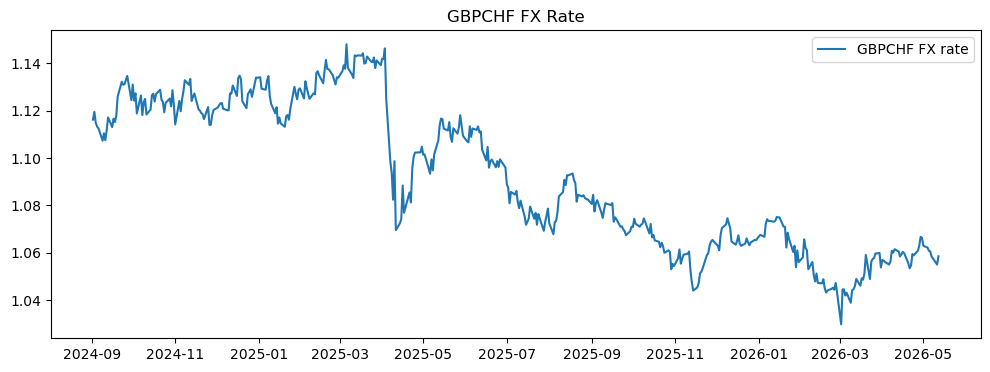

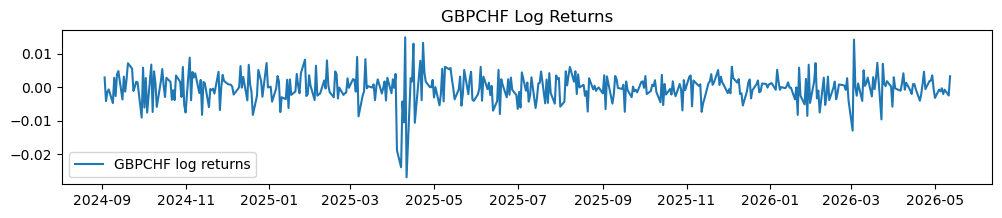

GBPCHF annualized vol: 0.06856255432790702


In [5]:
# --- Plot GBPCHF FX rate and log returns ---
fx_gbpchf = f1.fetch_csv('GBPCHF', data_params=config.data_params)
if 'close' in fx_gbpchf.columns:
    gbpchf = fx_gbpchf['close']
else:
    gbpchf = fx_gbpchf.iloc[:,0]  # fallback to first column if not named

plt.figure(figsize=(12, 4))
plt.plot(gbpchf.index, gbpchf, label='GBPCHF FX rate')
plt.title('GBPCHF FX Rate')
plt.legend()
plt.show()

# Plot GBPCHF log returns
import numpy as np
gbpchf_rets = np.log(gbpchf / gbpchf.shift(1))
plt.figure(figsize=(12, 2))
plt.plot(gbpchf_rets.index, gbpchf_rets, label='GBPCHF log returns')
plt.title('GBPCHF Log Returns')
plt.legend()
plt.show()

print('GBPCHF annualized vol:', gbpchf_rets.std() * np.sqrt(252))

## Equity correlation drift check
We’ll:
- compute a 60-day rolling average pairwise correlation across the equity ETFs in your `rets_df`.
- show the 1-year view you’re using now (limited by `XMWX`).
- also compute a 3-year view excluding `XMWX` (if data exist), to see whether the increase is structural or just recent.

In [6]:
# 1) Current 1-year view (already in rets_df)
# Pick equity ETFs present in rets_df
all_cols = list(rets_df.columns)
EQUITY_LIKE = [c for c in ["EMIM","GWX","BATG","XMWX","SGLN", 'YCA', 'VUAG'] if c in all_cols]

if len(EQUITY_LIKE) >= 2:
    rets_eq_1y = rets_df[EQUITY_LIKE]
    # 60D rolling average of pairwise correlation (off-diagonal mean)
    def offdiag_mean(corr_m):
        if corr_m.shape[0] < 2:
            return np.nan
        n = corr_m.shape[0]
        return (corr_m.values.sum() - n) / (n*(n-1))

    roll_avg_corr_1y = (
        rets_eq_1y.rolling(60).corr().groupby(level=0).apply(lambda c: offdiag_mean(c))
    )

    print("1Y rolling(60) avg pairwise equity corr (tail):")
    print(roll_avg_corr_1y.dropna().tail(756))
else:
    print("Not enough equity-like tickers to compute 1Y pairwise correlation.")

# 2) Longer 3Y view excluding XMWX (if data available): re-fetch or extend window is out of scope here,
# but we can approximate by checking if older data exist in prices_df; if not, we demonstrate exclusion-only.
try:
    # If you want to explicitly exclude XMWX to avoid its shorter history limiting the window
    EQUITY_NO_XMWX = [c for c in EQUITY_LIKE if c != "XMWX"]
    if len(EQUITY_NO_XMWX) >= 2:
        # Use available rets_df (1Y). For a true 3Y view, rerun 
        rets_eq_ex = rets_df[EQUITY_NO_XMWX]
        roll_avg_corr_ex = (
            rets_eq_ex.rolling(60).corr().groupby(level=0).apply(lambda c: offdiag_mean(c))
        )
        print("Ex-XMWX rolling(60) avg pairwise equity corr (tail):")
        print(roll_avg_corr_ex.dropna().tail(756))
    else:
        print("Not enough non-XMWX equity-like tickers to compute ex-XMWX correlation.")
except Exception as e:
    print("Correlation analysis note:", e)


1Y rolling(60) avg pairwise equity corr (tail):
Date
2024-11-26    0.335678
2024-11-27    0.331981
2024-11-29    0.332899
2024-12-02    0.305373
2024-12-03    0.292615
                ...   
2026-05-06    0.615535
2026-05-07    0.610755
2026-05-08    0.601628
2026-05-11    0.603772
2026-05-12    0.601394
Length: 357, dtype: float64
Ex-XMWX rolling(60) avg pairwise equity corr (tail):
Date
2024-11-26    0.242318
2024-11-27    0.238728
2024-11-29    0.239715
2024-12-02    0.210724
2024-12-03    0.199894
                ...   
2026-05-06    0.575129
2026-05-07    0.570570
2026-05-08    0.560960
2026-05-11    0.562159
2026-05-12    0.560949
Length: 357, dtype: float64


In [7]:

# Portfolio correlation matrix and risk summary
print('Correlation matrix:')
display(rets_df.corr())

risk_summary = risk_matrix.portfolio_risk(rets_df, w)
print('Portfolio risk summary:')
display(risk_summary)

# Display Percent Risk Contribution (PRC) column
import pandas as pd
pd.set_option('display.max_columns', None)
print('Percent Risk Contribution (PRC):')
display(risk_summary['PRC'])

Correlation matrix:


,XMWX,EMIM,GWX,VUAG,SGLN,BATG
XMWX,1.000000,0.716743,0.525099,0.674150,0.135216,0.701311
EMIM,0.716743,1.000000,0.492159,0.597325,0.188962,0.728854
GWX,0.525099,0.492159,1.000000,0.157808,0.220280,0.418291
VUAG,0.674150,0.597325,0.157808,1.000000,-0.047144,0.600782
SGLN,0.135216,0.188962,0.220280,-0.047144,1.000000,0.190953
BATG,0.701311,0.728854,0.418291,0.600782,0.190953,1.000000


INFO:geoquant.risk_matrix:++++++ portfolio_risk()


Portfolio risk summary:


{'port_vol': 0.1259162580801562,
 'cov_annual':           XMWX      EMIM       GWX      VUAG      SGLN      BATG
 XMWX  0.015627  0.014513  0.010686  0.012271  0.003593  0.023024
 EMIM  0.014513  0.026235  0.012978  0.014088  0.006506  0.031004
 GWX   0.010686  0.012978  0.026504  0.003741  0.007623  0.017884
 VUAG  0.012271  0.014088  0.003741  0.021202 -0.001459  0.022974
 SGLN  0.003593  0.006506  0.007623 -0.001459  0.045185  0.010660
 BATG  0.023024  0.031004  0.017884  0.022974  0.010660  0.068972,
 'corr':           XMWX      EMIM       GWX      VUAG      SGLN      BATG
 XMWX  1.000000  0.716743  0.525099  0.674150  0.135216  0.701311
 EMIM  0.716743  1.000000  0.492159  0.597325  0.188962  0.728854
 GWX   0.525099  0.492159  1.000000  0.157808  0.220280  0.418291
 VUAG  0.674150  0.597325  0.157808  1.000000 -0.047144  0.600782
 SGLN  0.135216  0.188962  0.220280 -0.047144  1.000000  0.190953
 BATG  0.701311  0.728854  0.418291  0.600782  0.190953  1.000000,
 'vol_ann': XMWX   

Percent Risk Contribution (PRC):


KeyError: 'PRC'